In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
from utils.backtester import BackTester
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from utils.data_fetcher import TickerPriceDataFetcher
import datetime
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
import lightgbm as lgb
import optuna
from indicators.returns import calculate_binary_forward_returns, calculate_binary_returns, calculate_binary_MA_returns, calculate_forward_returns, calculate_returns, calculate_MA_returns
from indicators.breakout import calculate_breakout
from indicators.volatility import calculate_atr, calculate_forward_vol
from indicators.volume import calculate_rel_volume
from indicators.trend import calculate_r2
import backtrader as bt
from strategies.base import BaseStrategy
import os
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from utils.helpers import PercentileScaler

Warning - Certain functionality 
             requires requests_html, which is not installed.
             
             Install using: 
             pip install requests_html
             
             After installation, you may have to restart your Python session.


c:\Users\alexr\AlgoTester\utils\data_fetcher.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:
rebalance_period = 21

# Preprocess data

In [34]:
from pypfopt.hierarchical_portfolio import HRPOpt

def test_hrp_portfolio(lookback_period=252, verbose=False):
    asset_dfs = {
        "GLD": pd.read_pickle('./data/raw/price/GLD_20250427.pkl'),
        "SPY": pd.read_pickle('./data/raw/price/SPY_20250427.pkl'),
        "TLT": pd.read_pickle('./data/raw/price/TLT_20250427.pkl'),
    }

    price_series = []
    for asset, df in asset_dfs.items():
        s = df['close'].rename(asset)
        price_series.append(s)
    # Join all closing prices on date (inner join)
    price_df = pd.concat(price_series, axis=1, join='inner')
    df_returns = price_df.pct_change().dropna()

    c = 0
    weights_col = []
    for i, r in tqdm(df_returns.iterrows(), total=len(df_returns)):
        if c % rebalance_period == 0:
            df_ = df_returns.loc[(df_returns.index <= i) & (df_returns.index > i - pd.Timedelta(days=lookback_period))]
            weights = {f: 1 for f in df_returns.columns}
            if len(df_) > 1:
                hrp_opt = HRPOpt(returns=df_)
                weights = hrp_opt.optimize()
        
        weights_col.append(weights)       
        c += 1

    df_returns['weights'] = weights_col
    df_returns

    class DynamicAllocation(BaseStrategy):

        params = (
            # ('lookback_periods', [21, 100, 252]),
            ('rebalance_period', 21),
            # ('dfs_vol', dict()),
            # ('vol_scaling_col', 'vol_scaling_percentile'),
            # ('asset_weights', dict()),
            # ('lookback_weights', dict()),
            ('df_weights', pd.DataFrame()),
        )

        def __init__(self):
            super().__init__()
            self.rebalance_day = 0
            self.df_weights = self.p.df_weights
            
        def next(self):
            super().next()
            if self.rebalance_day % self.p.rebalance_period == 0:
                current_capital = self.broker.getvalue()
                current_date = pd.to_datetime(self.datetime.date())
                
                current_weights = self.df_weights.loc[self.df_weights.index == current_date]
                if current_weights.shape[0] == 0:
                    current_weights = {f: 1 for f in self.p.tickers}
                else:
                    current_weights = current_weights['weights'].to_list()[0]
                

                for ticker in self.p.tickers:
                    data = self.getdatabyname(ticker)
                    current_position = self.broker.getposition(data).size
                    ticker_capital = current_capital * current_weights[ticker]
                    
                    target_position = ticker_capital / self.data.close[0]
                    # Submit order
                    self._submit_order(ticker, target_position - current_position, self.data.close[0])
            self.rebalance_day += 1



    btr = BackTester(asset_dfs)
    btr.add_strategy(
        DynamicAllocation, 
        tickers=asset_dfs.keys(), 
        price_data=asset_dfs, 
        rebalance_period=rebalance_period, 
        df_weights=df_returns,
    )
    results = btr.backtest()
    if verbose:
        btr.plot_results()
        for key in results:
            if key == 'returns': continue
            print(f"{key}: {results[key]:.2f}")
    
    return results['sharpe']

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/5140 [00:00<?, ?it/s]

  0%|          | 0/5140 [00:00<?, ?it/s]

  0%|          | 0/5140 [00:00<?, ?it/s]

  0%|          | 0/5140 [00:00<?, ?it/s]

...

  0%|          | 0/5140 [00:00<?, ?it/s]

  0%|          | 0/5140 [00:00<?, ?it/s]

  0%|          | 0/5140 [00:00<?, ?it/s]

  0%|          | 0/5140 [00:00<?, ?it/s]

  0%|          | 0/5140 [00:00<?, ?it/s]

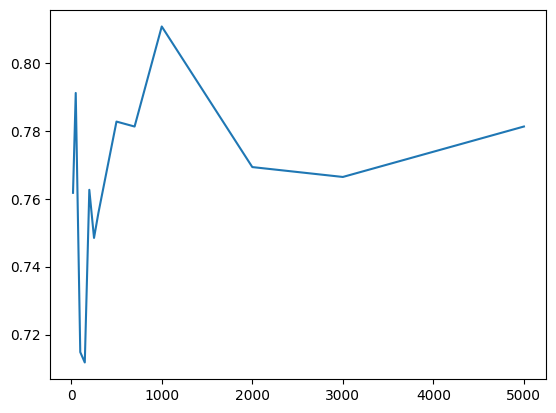

In [37]:
X = [20, 50, 100, 150, 200, 252, 300, 500, 700, 1000, 2000, 3000, 5000]
y = []
for x in tqdm(X):
    y.append(test_hrp_portfolio(x))

plt.plot(X, y)
plt.show()

In [2]:
import pandas as pd

def build_price_df(asset_dfs):
    """
    asset_dfs: dict {asset_name: DataFrame}, each must have 'close' column
    Returns a single DataFrame of closing prices, aligned by date (inner join).
    """
    price_series = []
    for asset, df in asset_dfs.items():
        s = df['close'].rename(asset)
        price_series.append(s)
    # Join all closing prices on date (inner join)
    price_df = pd.concat(price_series, axis=1, join='inner')
    return price_df

def compute_returns(price_df):
    """
    Converts prices to simple returns, drops the first NaN row.
    """
    return price_df.pct_change().dropna()


def last_n_covariance(returns, n):
    """
    returns: DataFrame of daily returns
    n: int, number of most recent days to use
    """
    last_r = returns.tail(n)
    cov    = last_r.cov()
    return last_r, cov


from pypfopt.hierarchical_portfolio import hrp_portfolio, plot_dendrogram

def hrp_weights_and_dendrogram(last_returns, cov_matrix):
    """
    last_returns: DataFrame of the last n returns
    cov_matrix: covariance matrix of last n returns

    Returns:
      - weights: pd.Series of HRP weights summing to 1
      - (also displays the dendrogram inline)
    """
    # 1) calculate HRP weights
    weights = hrp_portfolio(last_returns, cov_matrix)

    # 2) plot the dendrogram
    _ = plot_dendrogram(cov_matrix, figsize=(8, 4))
    
    return weights

def get_hrp_allocation(asset_dfs, n):
    # 1. Build price & returns
    price_df = build_price_df(asset_dfs)
    returns  = compute_returns(price_df)

    # 2. Last-n covariance
    last_r, cov = last_n_covariance(returns, n)

    # 3. HRP + dendrogram
    weights = hrp_weights_and_dendrogram(last_r, cov)
    return weights



n_days = 60
asset_dfs = {
    "GLD": pd.read_pickle('./data/raw/price/GLD_20250426.pkl'),
    "SPY": pd.read_pickle('./data/raw/price/SPY_20250426.pkl'),
    "TLT": pd.read_pickle('./data/raw/price/TLT_20250426.pkl'),
    # etc.
}
weights = get_hrp_allocation(asset_dfs, n_days)
print(weights)


ImportError: cannot import name 'hrp_portfolio' from 'pypfopt.hierarchical_portfolio' (c:\Users\alexr\miniconda3\envs\ai2\Lib\site-packages\pypfopt\hierarchical_portfolio.py)